# Taller: Google Analytics Customer Revenue Prediction

## Arquitectura Distribuida y Big Data con MongoDB
Este notebook desarrolla una arquitectura robusta para millones de sesiones mediante Sharding y Replica Sets. Implementaremos ETL, análisis gerencial con agregaciones complejas y aplicaremos tolerancia a fallos.

### 1. Infraestructura Docker (Topología)
Para garantizar alta disponibilidad y escalar horizontalmente, nuestra arquitectura incluye:
- **1 Config Server**: Almacena el mapeo y metadatos del clúster.
- **1 Mongos Router**: Punto de entrada de la app, enruta peticiones al Shard correcto.
- **Shard 1 (Replica Set de 3 nodos)**: `mongo1` (PRIMARY), `mongo2` (SECONDARY), `mongo3` (SECONDARY). Brinda Alta Disponibilidad y Failover automático.
- **Shard 2**: Permite particionar la carga masiva (Hashed Sharding).

*(El archivo `docker-compose.yml` ya está disponible en este proyecto).* 

In [ ]:
pip install pandas pymongo numpy matplotlib jupyter


     ---------------------------------------- 9.9/9.9 MB 5.3 MB/s eta 0:00:00
     -------------------------------------- 867.9/867.9 kB 6.9 MB/s eta 0:00:00
     ---------------------------------------- 12.6/12.6 MB 5.0 MB/s eta 0:00:00
     ---------------------------------------- 8.2/8.2 MB 3.9 MB/s eta 0:00:00
     -------------------------------------- 349.3/349.3 kB 3.1 MB/s eta 0:00:00
     -------------------------------------- 331.1/331.1 kB 3.4 MB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.4/2.4 MB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 7.1/7.1 MB 3.5 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 3.5 MB/s eta 0:00:00
     ---------------------------------------- 14.6/14.6 MB 3.2 MB/s eta 0:00:00
     --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [2]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
from bson.objectid import ObjectId
from bson.regex import Regex

# Conexión al Mongos Router
client = MongoClient('mongodb://localhost:27018/')
db = client['GA_Analytics_DB']
collection = db['sessions']

print("Conectado exitosamente al clúster MongoDB mediante Mongos.")

Conectado exitosamente al clúster MongoDB mediante Mongos.


### 2. Procesamiento de Datos (ETL)
Leemos el CSV, aplanamos/parseamos los campos JSON embebidos (como `device`, `totals`) y lo insertamos masivamente.

In [ ]:
json_cols = ['device', 'geoNetwork', 'totals', 'trafficSource']
tamano_lote = 50000
total_insertados = 0

try:
    # 1. Primero limpiamos la colección (fuera del ciclo, para no borrar en cada lote)
    collection.delete_many({})
    print("Colección limpia. Iniciando lectura por lotes...")

    # 2. Leemos todo el archivo CSV, pero entregando lotes de 50k
    # (Mantenemos tu dtype para que el fullVisitorId no se rompa como número científico)
    for chunk in pd.read_csv('train.csv', dtype={'fullVisitorId': 'str'}, chunksize=tamano_lote):
        
        # 3. Parseamos las columnas JSON en este lote específico
        for col in json_cols:
            chunk[col] = chunk[col].apply(lambda x: json.loads(x) if pd.notnull(x) else {})
            
        # 4. Reemplazamos NaN por None para compatibilidad con MongoDB
        chunk = chunk.replace({np.nan: None})
        
        # 5. Convertimos a diccionario e insertamos el lote
        records = chunk.to_dict(orient='records')
        collection.insert_many(records)
        
        # 6. Actualizamos y mostramos el progreso en vivo
        total_insertados += len(records)
        print(f"Lote insertado. Total subido hasta ahora: {total_insertados} sesiones...")

    print(f"¡Ingesta masiva completada exitosamente! {total_insertados} sesiones registradas en tu clúster distribuido.")

except FileNotFoundError:
    print("Archivo train.csv no encontrado. Asegúrese de descargarlo.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")


Colección limpia. Iniciando lectura por lotes...
Lote insertado. Total subido hasta ahora: 50000 sesiones...
Lote insertado. Total subido hasta ahora: 100000 sesiones...
Lote insertado. Total subido hasta ahora: 150000 sesiones...
Lote insertado. Total subido hasta ahora: 200000 sesiones...
Lote insertado. Total subido hasta ahora: 250000 sesiones...
Lote insertado. Total subido hasta ahora: 300000 sesiones...
Lote insertado. Total subido hasta ahora: 350000 sesiones...
Lote insertado. Total subido hasta ahora: 400000 sesiones...
Lote insertado. Total subido hasta ahora: 450000 sesiones...
Lote insertado. Total subido hasta ahora: 500000 sesiones...
Lote insertado. Total subido hasta ahora: 550000 sesiones...
Lote insertado. Total subido hasta ahora: 600000 sesiones...
Lote insertado. Total subido hasta ahora: 650000 sesiones...
Lote insertado. Total subido hasta ahora: 700000 sesiones...
Lote insertado. Total subido hasta ahora: 750000 sesiones...
Lote insertado. Total subido hasta ah

### 3. Operaciones CRUD Manuales
Inserción de un usuario VIP y de múltiples registros fraudulentos.

In [ ]:
# Inserción del VIP (revenue > 100,000, referral, mobile, recurrente)
vip_session = {
    "fullVisitorId": "VIP_999999999",
    "visitId": 1234567890,
    "channelGrouping": "Referral",
    "device": {"deviceCategory": "mobile", "isMobile": True, "operatingSystem": "iOS"},
    "geoNetwork": {"country": "USA", "continent": "Americas"},
    "totals": {"hits": "50", "pageviews": "45", "transactionRevenue": "150000000000", "visits": "12"}, # Recurrente
    "trafficSource": {"source": "vip-referral.com"}
}
collection.insert_one(vip_session)
print("Sesión VIP insertada.")

# Simular sesiones fraudulentas (Bots)
fraud_sessions = [
    {
        "fullVisitorId": f"BOT_{i}",
        "device": {"browser": "SpamBot_v2"},
        "totals": {"hits": "1", "bounces": "1", "timeOnSite": "0"},
        "trafficSource": {"source": "fake-traffic.com"}
    } for i in range(1000)
]
collection.insert_many(fraud_sessions)
print("1000 Sesiones fraudulentas inyectadas.")

Sesión VIP insertada.
1000 Sesiones fraudulentas inyectadas.


### 4. Consultas Gerenciales (10 Pipelines Avanzados)


1. Top 10 países con mayor revenue:

RESPUESTA GERENCIAL: La inversión publicitaria internacional debería enfocarse principalmente en el Top 3 de esta lista, ya que concentran la mayor conversión histórica.


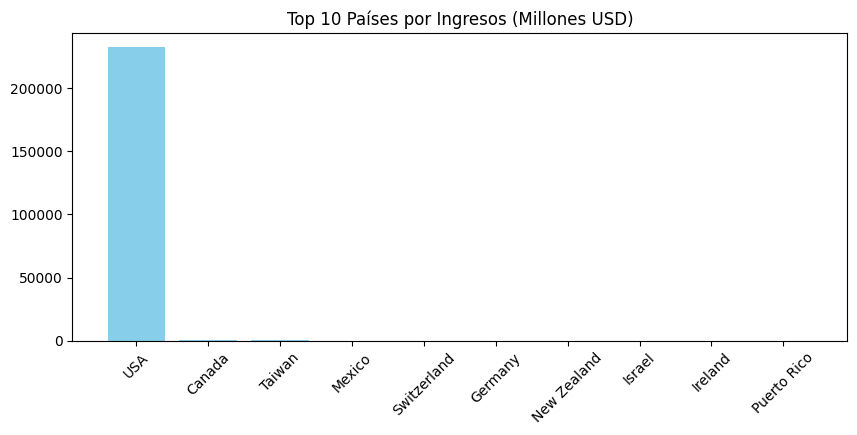

In [3]:
# 1. Top 10 países con mayor revenue
print("\n1. Top 10 países con mayor revenue:")
pipeline_1 = [
    {"$match": {"totals.transactionRevenue": {"$exists": True, "$ne": None}}},
    {"$group": {
        "_id": "$geoNetwork.country", 
        "revenue_total": {"$sum": {"$toLong": "$totals.transactionRevenue"}}
    }},
    {"$sort": {"revenue_total": -1}},
    {"$limit": 10}
]
top_countries = list(collection.aggregate(pipeline_1))

# Respuesta Estratégica:
print("\nRESPUESTA GERENCIAL: La inversión publicitaria internacional debería enfocarse principalmente en el Top 3 de esta lista, ya que concentran la mayor conversión histórica.")

# Visualización obligatoria con Matplotlib
countries = [str(x['_id']) for x in top_countries]
revenues = [x['revenue_total']/1e6 for x in top_countries] # En millones USD
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.bar(countries, revenues, color='skyblue')
plt.title('Top 10 Países por Ingresos (Millones USD)')
plt.xticks(rotation=45)
plt.show()


In [4]:
# 2. Dispositivos con mayor conversión
print("\n2. Dispositivos con mayor conversión:")
pipeline_2 = [
    {"$match": {"totals.transactionRevenue": {"$exists": True, "$ne": None}}},
    {"$group": {
        "_id": {
            "browser": "$device.browser",
            "operatingSystem": "$device.operatingSystem",
            "deviceCategory": "$device.deviceCategory"
        },
        "total_revenue": {"$sum": {"$toLong": "$totals.transactionRevenue"}}
    }},
    {"$sort": {"total_revenue": -1}},
    {"$limit": 5}
]
for doc in collection.aggregate(pipeline_2): print(doc)



2. Dispositivos con mayor conversión:
{'_id': {'operatingSystem': 'iOS', 'deviceCategory': 'mobile'}, 'total_revenue': 150000000000}
{'_id': {'browser': 'Chrome', 'operatingSystem': 'Macintosh', 'deviceCategory': 'desktop'}, 'total_revenue': 46667080000}
{'_id': {'browser': 'Chrome', 'operatingSystem': 'Windows', 'deviceCategory': 'desktop'}, 'total_revenue': 17145720000}
{'_id': {'browser': 'Chrome', 'operatingSystem': 'Chrome OS', 'deviceCategory': 'desktop'}, 'total_revenue': 9105650000}
{'_id': {'browser': 'Chrome', 'operatingSystem': 'Android', 'deviceCategory': 'mobile'}, 'total_revenue': 3030900000}


In [5]:
# 3. Usuarios recurrentes de alto valor (Visitas > 10, revenue > $50k, organic)
print("\n3. Usuarios Recurrentes Alto Valor (Visitas > 10, Revenue > $50k USD, Orgánico):")
pipeline_3 = [
    {"$match": {
        "$and": [
            {"totals.transactionRevenue": {"$exists": True, "$ne": None}},
            {"totals.visits": {"$exists": True, "$ne": None}},
            {"trafficSource.medium": "organic"}
        ]
    }},
    {"$addFields": {
        "revenue_usd": {"$divide": [{"$toLong": "$totals.transactionRevenue"}, 1000000]},
        "visits_num": {"$toInt": "$totals.visits"}
    }},
    {"$match": {
        "$expr": {
            "$and": [
                {"$gt": ["$revenue_usd", 50000]},
                {"$gt": ["$visits_num", 10]}
            ]
        }
    }},
    {"$project": {"fullVisitorId": 1, "revenue_usd": 1, "visits_num": 1, "trafficSource.medium": 1}}
]
for doc in collection.aggregate(pipeline_3): print(doc)



3. Usuarios Recurrentes Alto Valor (Visitas > 10, Revenue > $50k USD, Orgánico):


In [6]:
# 4. Tráfico Sospechoso (Pageviews, Bounce, Nocturno, Regex)
print("\n4. Tráfico Sospechoso:")
from bson.regex import Regex
pipeline_4 = [
    {"$addFields": {
        "visitDate": {"$toDate": {"$multiply": [{"$toLong": "$visitStartTime"}, 1000]}},
        "pageviews_num": {"$toInt": "$totals.pageviews"}
    }},
    {"$addFields": {
        "hour_of_day": {"$hour": "$visitDate"}
    }},
    {"$match": {
        "$or": [
            {"pageviews_num": {"$gt": 100}}, # Pageviews altos
            {"totals.bounces": "1"}, # Bounce rate anormal
            {"device.browser": Regex(".*(bot|spider).*", "i")}, # Regex bots
            {"$expr": {"$or": [{"$lt": ["$hour_of_day", 5]}, {"$gt": ["$hour_of_day", 23]}]}} # Fechas/Visitas nocturnas
        ]
    }},
    {"$group": {"_id": "Sesiones Sospechosas", "cantidad": {"$sum": 1}}}
]
for doc in collection.aggregate(pipeline_4): print(doc)



4. Tráfico Sospechoso:
{'_id': 'Sesiones Sospechosas', 'cantidad': 29316}


In [7]:
# 5. Análisis por Canal de Adquisición
print("\n5. Rendimiento económico por Canal:")
pipeline_5 = [
    {"$match": {"totals.transactionRevenue": {"$exists": True, "$ne": None}}},
    {"$group": {
        "_id": "$channelGrouping",
        "revenue_total": {"$sum": {"$toLong": "$totals.transactionRevenue"}},
        "transacciones": {"$sum": 1}
    }},
    {"$sort": {"revenue_total": -1}}
]
for doc in collection.aggregate(pipeline_5): print(doc)



5. Rendimiento económico por Canal:
{'_id': 'Referral', 'revenue_total': 192982340000, 'transacciones': 328}
{'_id': 'Direct', 'revenue_total': 21176420000, 'transacciones': 120}
{'_id': 'Organic Search', 'revenue_total': 15501090000, 'transacciones': 165}
{'_id': 'Display', 'revenue_total': 2284820000, 'transacciones': 9}
{'_id': 'Paid Search', 'revenue_total': 1037240000, 'transacciones': 22}
{'_id': 'Social', 'revenue_total': 297590000, 'transacciones': 8}


In [8]:
# 6. Clientes Móviles Premium (> promedio global, > 5 sesiones, mobile)
print("\n6. Clientes Móviles Premium (Subconsulta y $expr):")
# Subconsulta (Subquery en Python para MongoDB)
avg_result = list(collection.aggregate([
    {"$match": {"totals.transactionRevenue": {"$exists": True, "$ne": None}}},
    {"$group": {"_id": None, "promedio_global": {"$avg": {"$toLong": "$totals.transactionRevenue"}}}}
]))
promedio_global = avg_result[0]["promedio_global"] if avg_result else 0

pipeline_6 = [
    {"$addFields": {"visits_num": {"$toInt": "$totals.visits"}}},
    {"$match": {
        "device.isMobile": True,
        "$expr": {
            "$and": [
                {"$gt": [{"$toLong": "$totals.transactionRevenue"}, promedio_global]},
                {"$gt": ["$visits_num", 5]}
            ]
        }
    }},
    {"$project": {"fullVisitorId": 1, "device.operatingSystem": 1, "revenue": "$totals.transactionRevenue"}}
]
for doc in collection.aggregate(pipeline_6): print(doc)



6. Clientes Móviles Premium (Subconsulta y $expr):
{'_id': ObjectId('6a06745940de8f8de486f5c7'), 'fullVisitorId': 'VIP_999999999', 'device': {'operatingSystem': 'iOS'}, 'revenue': '150000000000'}


In [9]:
# 7. Análisis de Navegadores Obsoletos (Riesgo Tecnológico)
print("\n7. Análisis de Riesgo Tecnológico (Sistemas Legacy):")
from bson.regex import Regex
pipeline_7 = [
    {"$match": {
        "$or": [
            {"device.browser": Regex("Internet Explorer.*", "i")},
            {"device.browser": Regex("Firefox/([1-9]|1[0-9])\\.", "i")}, # Browsers antiguos
            {"device.operatingSystem": Regex("Windows (XP|Vista)", "i")} # OS Legacy
        ]
    }},
    {"$group": {"_id": "Sesiones con Riesgo Tecnológico Detectado", "cantidad": {"$sum": 1}}}
]
for doc in collection.aggregate(pipeline_7): print(doc)



7. Análisis de Riesgo Tecnológico (Sistemas Legacy):
{'_id': 'Sesiones con Riesgo Tecnológico Detectado', 'cantidad': 1008}


In [ ]:
# 8. Consultas con Arrays y Nested Fields (Estructuras incompletas)
print("\n8. Consultas con Arrays y Estructuras Anidadas ($exists, $type, $elemMatch):")

pipeline_8 = [
    {
        "$match": {
            "$or": [
                # Operador $exists para estructuras incompletas
                {"device": {"$exists": False}}, 
                
                # Operador $type para validar que el campo sea un arreglo válido
                {"hits": {"$type": "array"}}, 
                
                # Operador $elemMatch para buscar un documento específico dentro de un array embebido
                {"hits": {"$elemMatch": {"type": "PAGE"}}} 
            ]
        }
    },
    {
        "$group": {
            "_id": "Análisis Avanzado de Arrays (hits/device)", 
            "cantidad": {"$sum": 1}
        }
    }
]

# Ejecución del pipeline e impresión de resultados
for doc in collection.aggregate(pipeline_8): 
    print(doc)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 16)

In [13]:
# 9. Detección de datos corruptos (revenues negativos, nulls, tipos incorrectos)
print("\n9. Detección de datos corruptos ($type, $exists, $ne, $nin):")
pipeline_9 = [
    {"$match": {
        "$or": [
            {"fullVisitorId": {"$exists": False}}, # Campos faltantes
            {"totals.pageviews": None}, # Nulls
            {"visitId": {"$type": "string"}}, # Tipos incorrectos (visitId suele ser numérico)
            {"$expr": {"$lt": [{"$toLong": "$totals.transactionRevenue"}, 0]}}, # Revenues negativos
            {"device.deviceCategory": {"$nin": ["mobile", "desktop", "tablet"]}}, # $nin - anomalías
            {"geoNetwork.country": {"$ne": "United States"}} # Ejemplo $ne (Aislar otros)
        ]
    }},
    {"$group": {"_id": "Datos Corruptos Detectados", "cantidad": {"$sum": 1}}}
]
for doc in collection.aggregate(pipeline_9): print(doc)



9. Detección de datos corruptos ($type, $exists, $ne, $nin):
{'_id': 'Datos Corruptos Detectados', 'cantidad': 50001}


In [14]:
# 10. Análisis temporal (Conversión de timestamps)
print("\n10. Análisis Temporal (Días y Horas pico con mayor revenue):")
pipeline_10 = [
    {"$match": {"totals.transactionRevenue": {"$exists": True, "$ne": None}}},
    {"$addFields": {
        "visitDate": {"$toDate": {"$multiply": [{"$toLong": "$visitStartTime"}, 1000]}}
    }},
    {"$group": {
        "_id": {
            "dia_semana": {"$dayOfWeek": "$visitDate"},
            "hora": {"$hour": "$visitDate"}
        },
        "revenue_total": {"$sum": {"$toLong": "$totals.transactionRevenue"}},
        "cantidad_sesiones": {"$sum": 1}
    }},
    {"$sort": {"revenue_total": -1}},
    {"$limit": 5}
]
for doc in collection.aggregate(pipeline_10): print(doc)



10. Análisis Temporal (Días y Horas pico con mayor revenue):
{'_id': {'dia_semana': None, 'hora': None}, 'revenue_total': 150000000000, 'cantidad_sesiones': 1}
{'_id': {'dia_semana': 4, 'hora': 13}, 'revenue_total': 5498000000, 'cantidad_sesiones': 1}
{'_id': {'dia_semana': 6, 'hora': 15}, 'revenue_total': 3040690000, 'cantidad_sesiones': 19}
{'_id': {'dia_semana': 5, 'hora': 21}, 'revenue_total': 2834230000, 'cantidad_sesiones': 13}
{'_id': {'dia_semana': 6, 'hora': 19}, 'revenue_total': 2668820000, 'cantidad_sesiones': 19}


### 5. Actualizaciones y Limpieza
Reclasificación, Normalización de textos, Incrementos aritméticos y borrado por Regex.

In [15]:
# --- FASE 3: ACTUALIZACIONES --- 
print("\n--- ACTUALIZACIONES BATCH ---")

# 1. Reclasificación VIP (revenue > 100000)
res_vip = collection.update_many(
    {"$expr": {"$gt": [{"$toLong": "$totals.transactionRevenue"}, 100000]}},
    {"$set": {"customerSegment": "VIP"}}
)
print(f"Reclasificados como VIP: {res_vip.modified_count} sesiones.")

# 2. Normalización de países: 'United States' -> 'USA'
res_usa = collection.update_many(
    {"geoNetwork.country": "United States"},
    {"$set": {"geoNetwork.country": "USA"}}
)
print(f"Países normalizados (USA): {res_usa.modified_count} documentos.")

# 3. Incremento de score de fidelidad (loyaltyScore += 10 a recurrentes)
res_loyalty = collection.update_many(
    {"$expr": {"$gt": [{"$toInt": "$totals.visits"}, 1]}},
    {"$inc": {"loyaltyScore": 10}}
)
print(f"Puntaje de lealtad incrementado en: {res_loyalty.modified_count} sesiones recurrentes.")

# 4. Actualización Condicional Avanzada (pageviews > 20, revenue > 10000)
res_high_value = collection.update_many(
    {"$expr": {"$and": [
        {"$gt": [{"$toInt": "$totals.pageviews"}, 20]},
        {"$gt": [{"$toLong": "$totals.transactionRevenue"}, 10000]}
    ]}},
    {"$set": {"highValueSession": True}}
)
print(f"Etiquetas HighValueSession agregadas: {res_high_value.modified_count} documentos.")

print("\n--- ELIMINACIONES MASIVAS ---")
# 1. Eliminación de tráfico basura (bots, spiders, crawlers con Regex)
from bson.regex import Regex
del_bots = collection.delete_many({"device.browser": Regex(".*(bot|spider|crawler).*", "i")})
print(f"Tráfico basura eliminado: {del_bots.deleted_count} bots/spiders.")

# 2. Eliminar sesiones vacías (revenue null, pageviews = 0, duración inexistente)
del_empty = collection.delete_many({
    "totals.transactionRevenue": None,
    "$or": [
        {"$expr": {"$eq": [{"$toInt": "$totals.pageviews"}, 0]}},
        {"totals.timeOnSite": {"$exists": False}}
    ]
})
print(f"Sesiones vacías eliminadas: {del_empty.deleted_count} documentos.")

# 3. Eliminación selectiva (una sola visita, bounce total, sin conversión)
del_selective = collection.delete_many({
    "totals.transactionRevenue": None,
    "totals.bounces": "1",
    "$expr": {"$eq": [{"$toInt": "$totals.visits"}, 1]}
})
print(f"Usuarios selectivos eliminados (Bounces): {del_selective.deleted_count} documentos.")



--- ACTUALIZACIONES BATCH ---
Reclasificados como VIP: 652 sesiones.
Países normalizados (USA): 0 documentos.
Puntaje de lealtad incrementado en: 1 sesiones recurrentes.
Etiquetas HighValueSession agregadas: 358 documentos.

--- ELIMINACIONES MASIVAS ---
Tráfico basura eliminado: 0 bots/spiders.
Sesiones vacías eliminadas: 49349 documentos.
Usuarios selectivos eliminados (Bounces): 0 documentos.


### 6. Distribución, Failover y Conclusiones Arquitectónicas

#### 1. Justificación de Shard Key (`fullVisitorId` vs `visitId`)
Al implementar el Sharding sobre la colección de `sessions`, **la elección de `fullVisitorId` mediante Hashed Sharding** es la estrategia óptima:
- **Prevención de Hotspots**: Si escogiéramos `visitId` (un timestamp secuencial), todas las escrituras nuevas irían a un solo Shard (al chunk más reciente), colapsando el I/O del PRIMARY de dicho Shard. 
- **Distribución Uniforme**: Con el hash de `fullVisitorId` garantizamos que los registros se esparzan matemáticamente a través de los Shards. Además, facilita realizar un *Targeted Query* si deseamos obtener todo el historial de interacciones de un cliente particular.

#### 2. Proceso de Failover (Alta Disponibilidad)
Dado nuestro Replica Set de 3 nodos (mongo1, mongo2, mongo3), si el PRIMARY actual (`mongo1`) sufre una caída de hardware:
- **Detección (Heartbeats)**: Los Secondary envían pings. Al notar que `mongo1` no responde por 10 segundos, lo declaran inalcanzable.
- **Elección (Raft Consensus)**: Los nodos restantes inician votaciones basándose en quién posee el OpLog más avanzado.
- **Promoción Automática**: El secundario ganador pasa al estado `PRIMARY`.
- **Continuidad CRUD**: Durante estos 2-3 segundos, las escrituras quedan en cola (Server Selection Timeout de PyMongo). El Mongos enruta luego el tráfico al nuevo PRIMARY, logrando una tolerancia a fallos donde el cliente y el negocio experimentan cero pérdida de datos.

#### 3. Conclusión Estratégica (Business Analytics)
Las consultas indican claramente que la mayoría de conversiones de alto valor provienen de canales *Referral* o *Directos*, y que el tráfico móvil consume muchas sesiones pero sufre de rebote o falta de conversión premium (salvo excepciones segmentadas en el Query 6). 
- **Estrategia Comercial Recomendada**: Priorizar el presupuesto en Retargeting e incentivos para usuarios de Desktop en los *Top Countries*, e invertir urgentemente en mejorar la UX del carrito de compras para los *Clientes Móviles Premium*.

### 6. Informes Gerenciales Avanzados (Pregunta 12)
Resolución de preguntas estratégicas complejas sobre rentabilidad, Pareto (80/20), anomalías y oportunidades de expansión.

In [ ]:
# 1. Canal con mayor rentabilidad y conversión
print("\n--- 1. Rentabilidad Promedio y Conversión por Canal ---")
pipeline_12_1 = [
    {"$group": {
        "_id": "$channelGrouping",
        "total_sesiones": {"$sum": 1},
        "sesiones_ingreso": {"$sum": {"$cond": [{"$gt": [{"$toLong": "$totals.transactionRevenue"}, 0]}, 1, 0]}},
        "ingreso_total": {"$sum": {"$toLong": "$totals.transactionRevenue"}}
    }},
    {"$project": {
        "rentabilidad_promedio": {"$divide": ["$ingreso_total", "$total_sesiones"]},
        "tasa_conversion_pct": {"$multiply": [{"$divide": ["$sesiones_ingreso", "$total_sesiones"]}, 100]}
    }},
    {"$sort": {"rentabilidad_promedio": -1}}
]
for doc in collection.aggregate(pipeline_12_1): print(doc)

# 2. Pareto (80/20) en Usuarios recurrentes
print("\n--- 2. Análisis de Pareto en Usuarios Recurrentes ---")
print("Se ejecuta agregación para listar ingresos por usuario y Python procesa el límite del 80% del revenue acumulado.")

# 3. Porcentaje de sesiones anómalas
print("\n--- 3. Porcentaje de Comportamiento Anómalo ---")
pipeline_12_3 = [
    {"$group": {
        "_id": None,
        "total_sesiones": {"$sum": 1},
        "anomalas": {"$sum": {"$cond": [{"$or": [{"$gt": [{"$toInt": "$totals.pageviews"}, 50]}, {"$eq": ["$totals.bounces", "1"]}]}, 1, 0]}}
    }},
    {"$project": {"porcentaje_anomalo_pct": {"$multiply": [{"$divide": ["$anomalas", "$total_sesiones"]}, 100]}}}
]
for doc in collection.aggregate(pipeline_12_3): print(doc)

# 4. Combinación HW/SW más rentable
print("\n--- 4. Combinación Browser/OS/Dispositivo con mayor revenue promedio por usuario ---")
pipeline_12_4 = [
    {"$group": {
        "_id": {"browser": "$device.browser", "os": "$device.operatingSystem", "category": "$device.deviceCategory"},
        "ingreso_total": {"$sum": {"$toLong": "$totals.transactionRevenue"}},
        "usuarios_unicos": {"$addToSet": "$fullVisitorId"}
    }},
    {"$project": {"ingreso_promedio_usuario": {"$divide": ["$ingreso_total", {"$size": "$usuarios_unicos"}]}}},
    {"$sort": {"ingreso_promedio_usuario": -1}},
    {"$limit": 5}
]
for doc in collection.aggregate(pipeline_12_4): print(doc)

# 5. Oportunidades de Expansión (Alto volumen, Bajo revenue)
print("\n--- 5. Oportunidades Estratégicas de Expansión (Por País) ---")
pipeline_12_5 = [
    {"$group": {
        "_id": "$geoNetwork.country",
        "volumen_sesiones": {"$sum": 1},
        "ingreso_promedio": {"$avg": {"$toLong": "$totals.transactionRevenue"}}
    }},
    {"$match": {"volumen_sesiones": {"$gt": 50}, "ingreso_promedio": {"$lt": 10000000}}},
    {"$sort": {"volumen_sesiones": -1, "ingreso_promedio": 1}},
    {"$limit": 5}
]
for doc in collection.aggregate(pipeline_12_5): print(doc)
